### Looking for the blind spots of circular harmonics
* Test the blind spots of circular harmonics 

#### Basis functions that are combined into inputs
* $p_1(r, \theta) =  e^{i\theta}$
* $p_2(r, \theta) =  e^{2i\theta}$ 
* And the rotated version by $\frac{\pi}{2}$

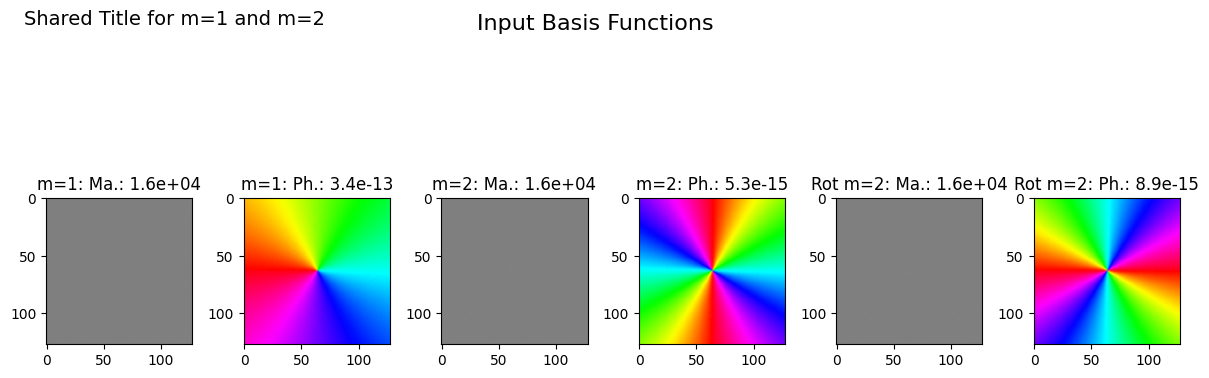

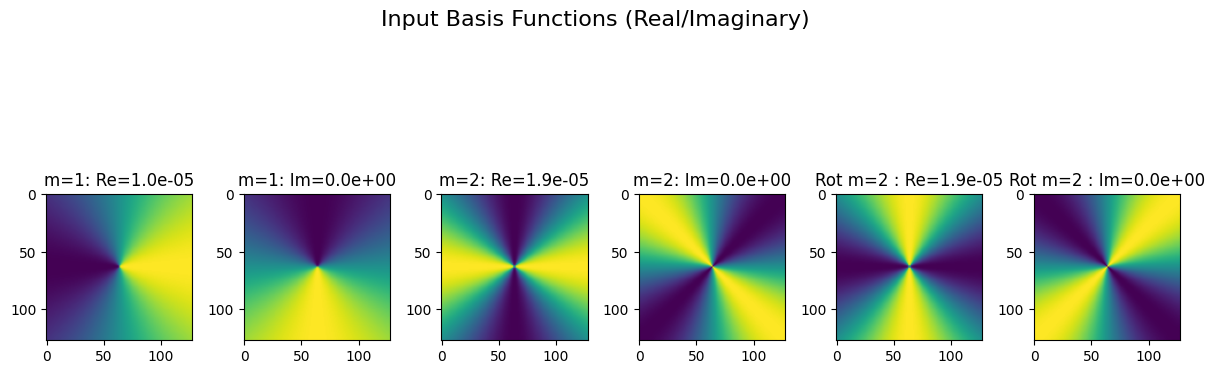

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from einops import repeat
from lovely_tensors import monkey_patch
monkey_patch()

def get_circular_harmonics(order, n_points): 
    # Create a Cartesian grid over the unit disk
    x = torch.linspace(-1, 1, n_points, device=device)
    y = torch.linspace(-1, 1, n_points, device=device)
    X, Y = torch.meshgrid(x, y, indexing='xy')
    # Convert to polar coordinates
    R = torch.sqrt(X**2 + Y**2)
    Theta = torch.atan2(Y, X)
    # Force any value near -pi to be exactly pi:
    Theta[torch.abs(Theta + np.pi) < 1e-6] = np.pi
    # Mask for points outside the unit circle
    mask = R > 1
    return mask, torch.exp(1j * order * Theta).to(torch.complex128)

def plot_mag_phase(p, title, fig, ax1, ax2):
    mag = torch.sum(p.abs()).item()
    ang = torch.sum(p.angle()).item()
    ax1.imshow(p.abs(), cmap='gray', vmin=0, vmax=2)
    ax1.set_aspect('equal')
    ax1.set_title(f'{title}: Ma.: {mag:.1e}' )
    im = ax2.imshow(p.angle(), cmap='hsv', vmin=-np.pi, vmax=np.pi,)
    ax2.set_aspect('equal')
    ax2.set_title(f'{title}: Ph.: {ang:.1e}')
    return fig 

def plot_complex(p, title, fig, ax1, ax2):
    real = torch.sum(p.real).item()
    imag = torch.sum(p.imag).item()
    ax1.imshow(p.real) 
    ax1.set_aspect('equal')
    ax1.set_title(f'{title}: Re={real:.1e}')
    ax2.imshow(p.imag)
    ax2.set_aspect('equal')
    ax2.set_title(f'{title}: Im={imag:.1e}')
    return fig 

# Choose device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mask_img, p_1 = get_circular_harmonics(1, 128)
mask_img, p_2 = get_circular_harmonics(2, 128)
p_2_rot = torch.rot90(p_2.clone(), k=1)
fig, axs = plt.subplots(1, 6, figsize=(12, 5)) 
_ = plot_mag_phase(p_1, "m=1", fig, axs[0], axs[1])
fig.text(0.15, 0.95, "Shared Title for m=1 and m=2", ha='center', va='bottom', fontsize=14)
_ = plot_mag_phase(p_2, "m=2", fig, axs[2], axs[3])
_ = plot_mag_phase(p_2_rot, "Rot m=2", fig, axs[4], axs[5])
#fig.colorbar(axs[1].images[0], ax=axs[1], orientation='vertical', fraction=0.02, pad=0.04)
fig.suptitle("Input Basis Functions", fontsize=16)
plt.tight_layout()
# Real/Imaginary plots
fig, axs = plt.subplots(1, 6, figsize=(12, 5))
_ = plot_complex(p_1, "m=1", fig, axs[0], axs[1])
_ = plot_complex(p_2, "m=2", fig, axs[2], axs[3])
_ = plot_complex(p_2_rot, "Rot m=2 ", fig, axs[4], axs[5])
fig.suptitle("Input Basis Functions (Real/Imaginary)", fontsize=16)
# Show the colorbar for phase plots
plt.tight_layout()
plt.show()

### Inputs with monomial and rotated polynomial
 * $f_1 = e^{i\theta} + e^{2i\theta}$
 * $f_2 = e^{i\theta+\frac{\pi}{2}} + e^{2i(\theta+\frac{\pi}{2})}$
 * rot $f_1 = e^{i\theta} + e^{2i(\theta+\frac{\pi}{2})}$

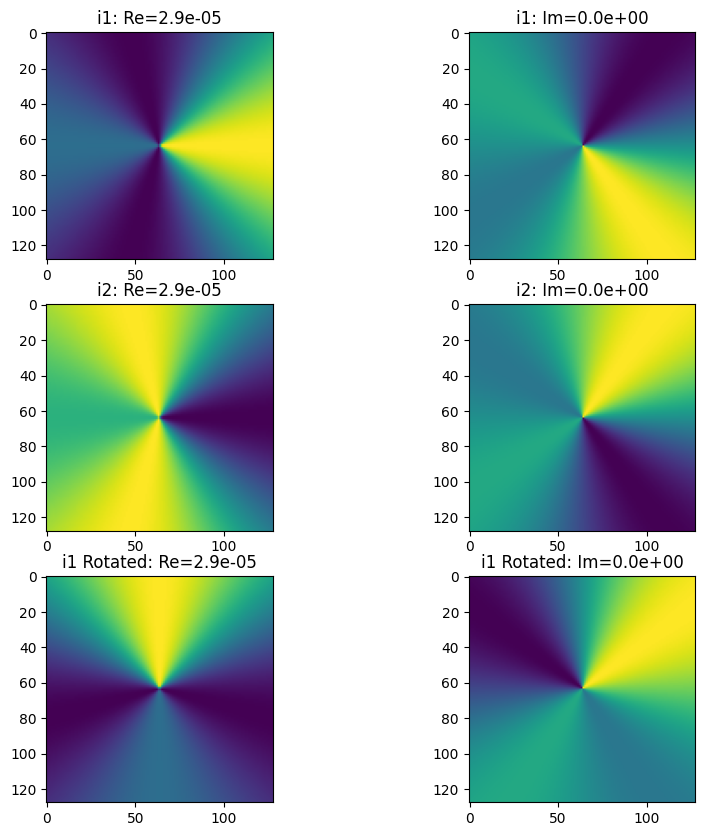

In [8]:
fig, (axs1, axs2, axs3) = plt.subplots(3, 2, figsize=(10, 10))
i_1 = p_1+p_2
_ = plot_complex(i_1, "i1", fig, axs1[0], axs1[1])
i_2 = torch.rot90(p_1+p_2_rot, k=2)
_ = plot_complex(i_2, "i2", fig, axs2[0], axs2[1])
rot_i_1 = torch.rot90(torch.clone(i_1), k=1)
_ = plot_complex(rot_i_1, "i1 Rotated", fig, axs3[0], axs3[1])

#### Harmonic Filters used in convolution

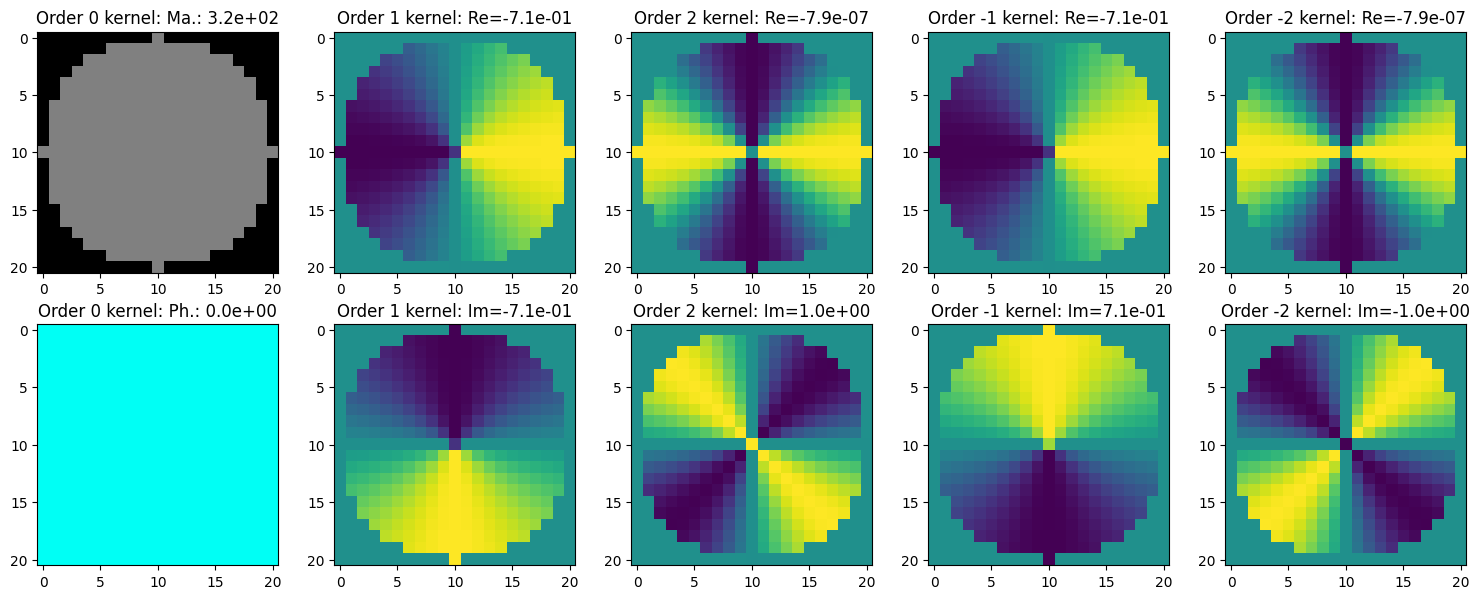

torch.Size([5, 21, 21])

In [9]:
FILTER_SIZE = 21
# Create a small filter for convolution using a transposed layout:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))

mask, f_0 = get_circular_harmonics(0, FILTER_SIZE)
f_0 *= ~mask
# For order 0, use plot_mag_phase (top: magnitude, bottom: phase)
plot_mag_phase(f_0, "Order 0 kernel", fig, axs[0,0], axs[1,0])

mask, f_1 = get_circular_harmonics(1, FILTER_SIZE)
f_1 *= ~mask
# For order 1 kernel, use plot_complex (top: real, bottom: imaginary)
_ = plot_complex(f_1, "Order 1 kernel", fig, axs[0,1], axs[1,1])

mask, f_2 = get_circular_harmonics(2, FILTER_SIZE)
f_2 *= ~mask
_ = plot_complex(f_2, "Order 2 kernel", fig, axs[0,2], axs[1,2])

mask, f_neg1 = get_circular_harmonics(-1, FILTER_SIZE)
f_neg1 *= ~mask
_ = plot_complex(f_neg1, "Order -1 kernel", fig, axs[0,3], axs[1,3])

mask, f_neg2 = get_circular_harmonics(-2, FILTER_SIZE)
f_neg2 *= ~mask
_ = plot_complex(f_neg2, "Order -2 kernel", fig, axs[0,4], axs[1,4])

plt.tight_layout()
plt.show()

# Stack the filters into a single tensor
kernel_orders = [-2, -1, 0, 1, 2]
filters = torch.stack([f_neg2, f_neg1, f_0, f_1, f_2], dim=0)
filters.shape


In [10]:
channels1 = torch.conv2d(repeat(i_1, 'h w -> 1 5 h w',), 
             weight=repeat(filters, 'f h w -> f 1 h w'),
             groups=5)
channels2 = torch.conv2d(repeat(i_2, 'h w -> 1 5 h w',),
             weight=repeat(filters, 'f h w -> f 1 h w'),
             groups=5)
channels_rot1 = torch.conv2d(repeat(rot_i_1, 'h w -> 1 5 h w',),
             weight=repeat(filters, 'f h w -> f 1 h w'),
             groups=5)

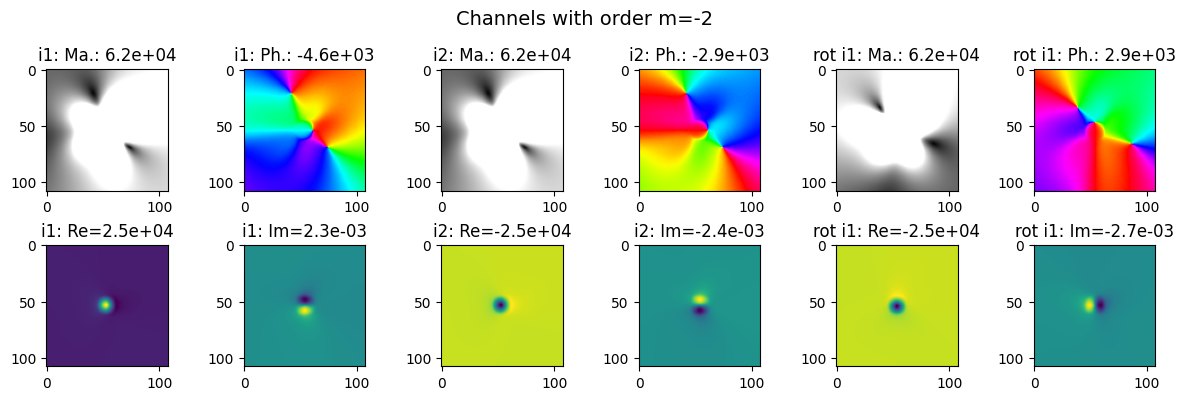

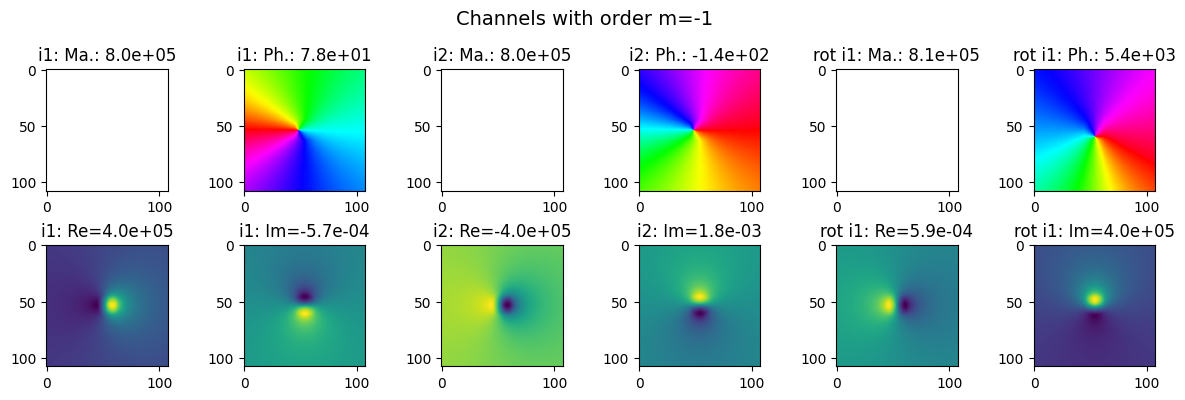

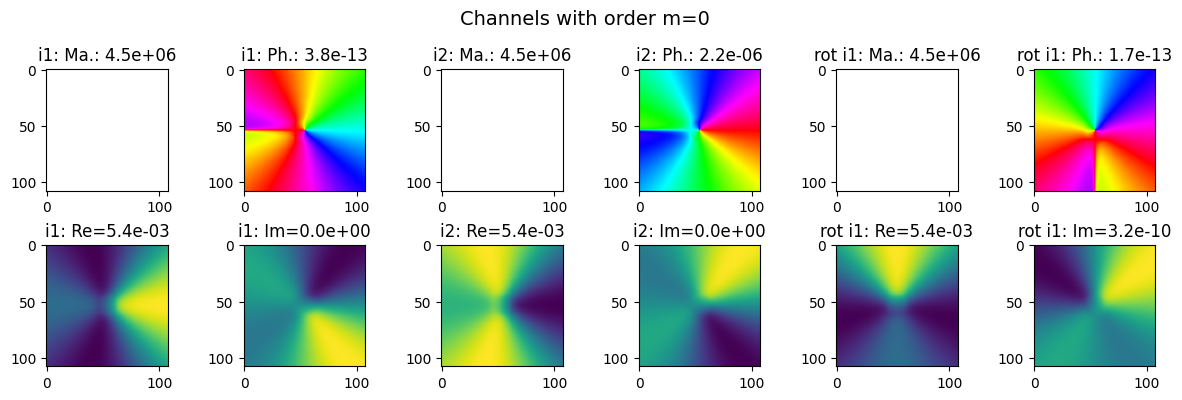

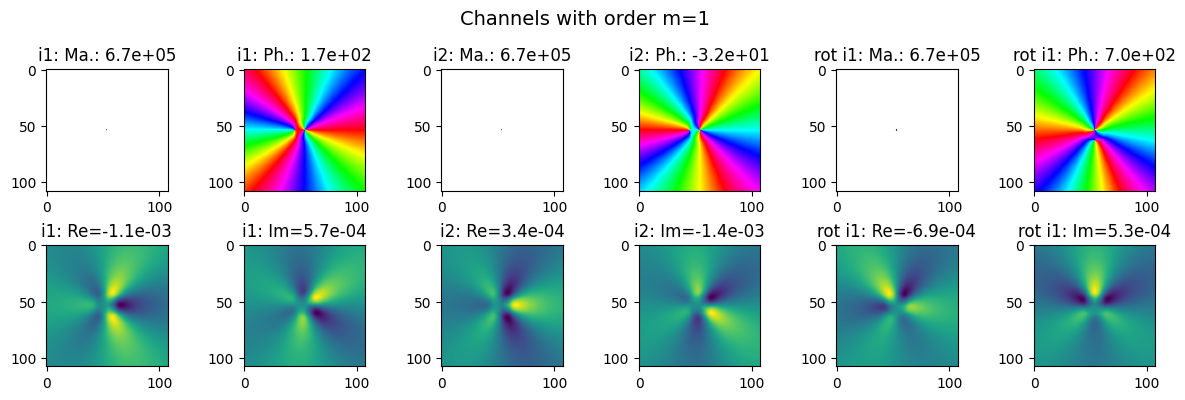

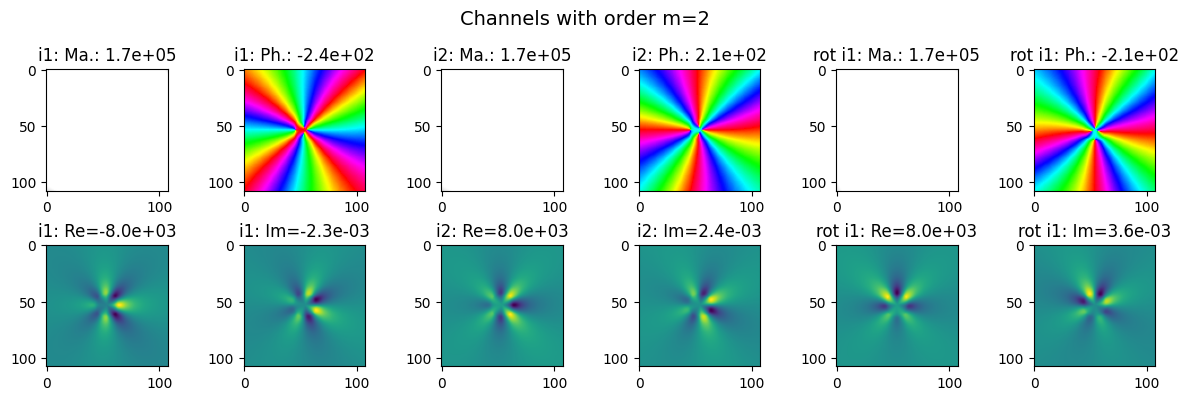

In [11]:
for idx, order in enumerate(kernel_orders):
    fig, (axs1, axs2) = plt.subplots(2, 6, figsize=(12, 4))
    axs = axs1
    _ = plot_mag_phase(channels1[0][idx], f"i1", fig, axs[0], axs[1])
    _ = plot_mag_phase(channels2[0][idx], f"i2", fig, axs[2], axs[3])
    _ = plot_mag_phase(channels_rot1[0][idx], f"rot i1", fig, axs[4], axs[5])
    axs = axs2
    _ = plot_complex(channels1[0][idx], f"i1", fig, axs[0], axs[1])
    _ = plot_complex(channels2[0][idx], f"i2", fig, axs[2], axs[3])
    _ = plot_complex(channels_rot1[0][idx], f"rot i1", fig, axs[4], axs[5])
    # Set xlabel for the the fig
    fig.suptitle(f"Channels with order m={order}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [12]:
from complex_invariants_2d import get_complex_monomial
# Get the complex monomial for m=1, n=1
p_11 =  get_complex_monomial(i_1.shape[-1], 1, 1)

def get_moment(array, p): 
    pi_pq = get_complex_monomial(array.shape[-1], p, p)
    return torch.sum((array-torch.min(array))/torch.max(array) * pi_pq, dim=(-1, -2))

for idx, order in enumerate(kernel_orders):
    abs1 = channels1[0][idx].abs()
    abs2 = channels2[0][idx].abs()
    abs_rot1 = channels_rot1[0][idx].abs()
    print(f"Moments real from absolute channels m={order} i1: {get_moment(abs1, 1).real:.4e}, i2: {get_moment(abs2, 1).real:.4e}, rot i1: {get_moment(abs_rot1, 1).real:.4e}")
    print(f"Moments imag from absolute channels m={order} i1: {get_moment(abs1, 1).imag:.4e}, i2: {get_moment(abs2, 1).imag:.4e}, rot i1: {get_moment(abs_rot1, 1).imag:.4e}")
    if order == 0: 
        real1 = channels1[0][idx].real
        imag1 = channels1[0][idx].imag
        real2 = channels2[0][idx].real
        imag2 = channels2[0][idx].imag
        real_rot1 = channels_rot1[0][idx].real
        imag_rot1 = channels_rot1[0][idx].imag
        print(f"Moments real from complex channels real m={order} i1: {get_moment(real1, 1).real:.4e}, i2: {get_moment(real2, 1).real:.4e}, rot i1: {get_moment(real_rot1, 1).real:.4e}")
        print(f"Moments imag from complex channels imag m={order} i1: {get_moment(imag1, 1).imag:.4e}, i2: {get_moment(imag2, 1).imag:.4e}, rot i1: {get_moment(imag_rot1, 1).imag:.4e}")

Moments real from absolute channels m=-2 i1: 4.2730e+01, i2: 4.2730e+01, rot i1: 4.2730e+01
Moments imag from absolute channels m=-2 i1: 2.0272e-18, i2: 2.0272e-18, rot i1: 2.0272e-18
Moments real from absolute channels m=-1 i1: 4.9305e+02, i2: 4.9305e+02, rot i1: 5.0835e+02
Moments imag from absolute channels m=-1 i1: 4.8541e-19, i2: 4.8541e-19, rot i1: -4.4962e-19
Moments real from absolute channels m=0 i1: 4.9965e+03, i2: 4.9965e+03, rot i1: 4.9965e+03
Moments imag from absolute channels m=0 i1: -2.7117e-31, i2: 2.8731e-24, rot i1: 9.8608e-31
Moments real from complex channels real m=0 i1: 4.4438e+03, i2: 1.4120e+04, rot i1: 4.4438e+03
Moments imag from complex channels imag m=0 i1: -9.2082e-16, i2: 9.2082e-16, rot i1: 9.2082e-16
Moments real from absolute channels m=1 i1: 2.0513e+03, i2: 2.0513e+03, rot i1: 2.0909e+03
Moments imag from absolute channels m=1 i1: -4.5812e-18, i2: -4.5812e-18, rot i1: 4.7491e-18
Moments real from absolute channels m=2 i1: 5.1321e+02, i2: 5.1321e+02, r

In [13]:
# Second convolution prepare filters with orders resulting in zero
filters2 = torch.stack([f_2, f_1, f_0, f_neg1, f_neg2], dim=0)[:, None]
kernel_orders2 = [2, 1, 0, -1, -2]
s_channels1 = torch.conv2d(channels1, 
                           weight=filters2,
                           groups=5)
s_channels2 = torch.conv2d(channels2, 
                           weight=filters2,
                           groups=5)
s_channels_rot1 = torch.conv2d(channels_rot1, 
                           weight=filters2,
                           groups=5)
                        

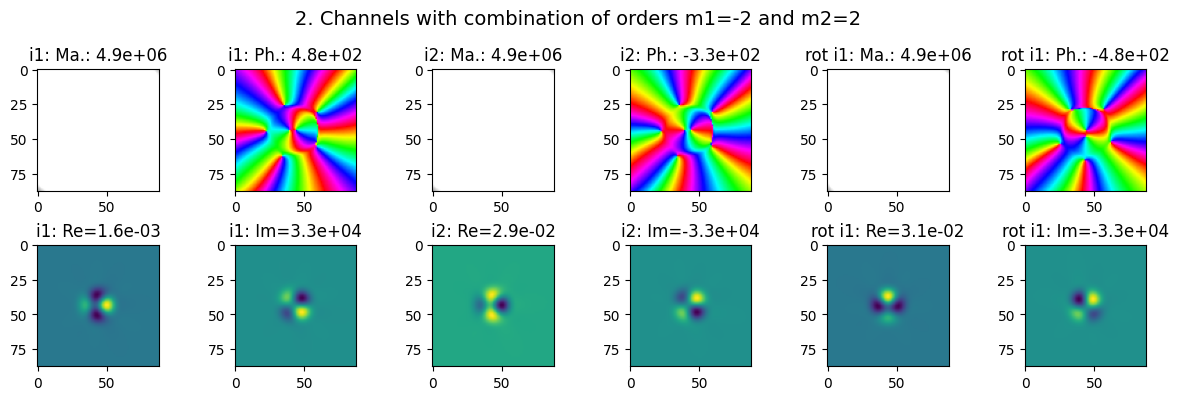

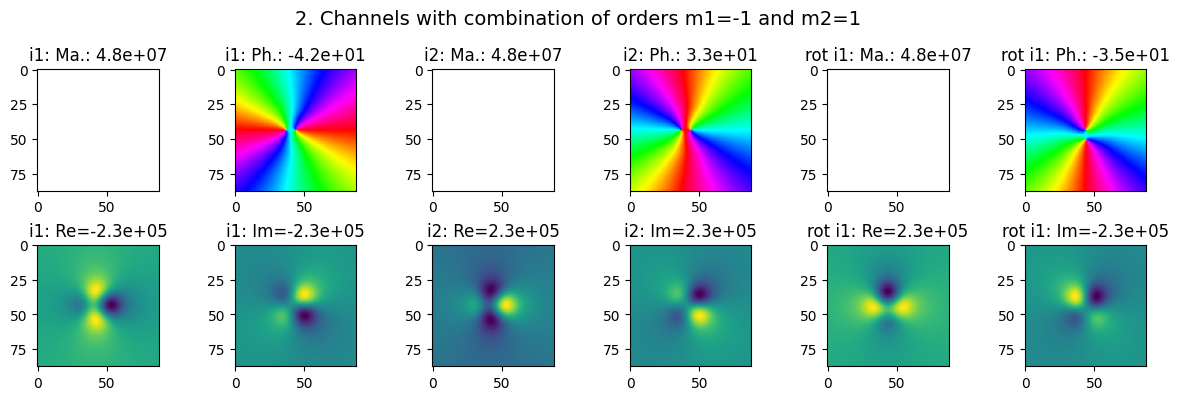

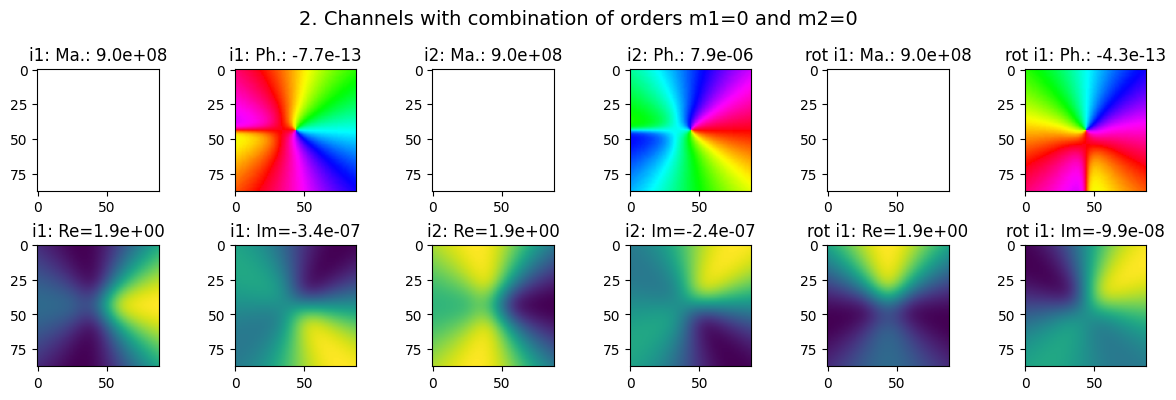

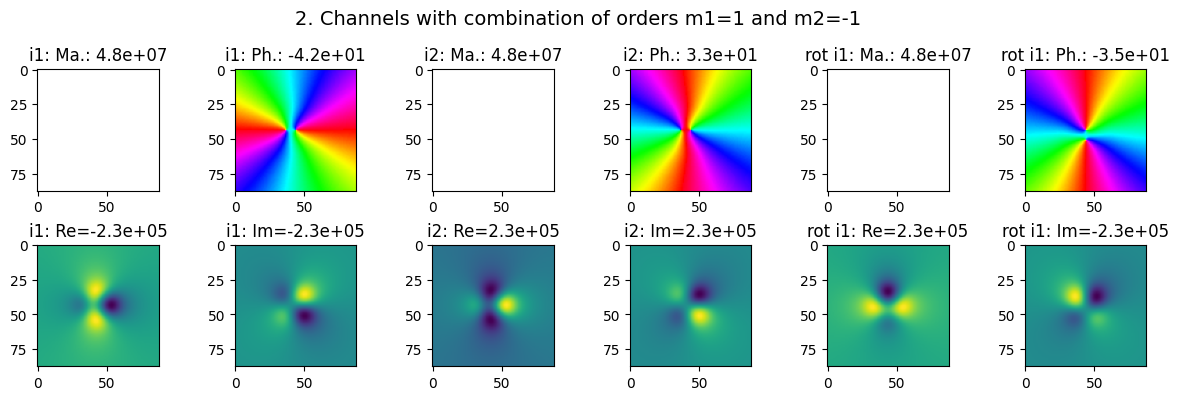

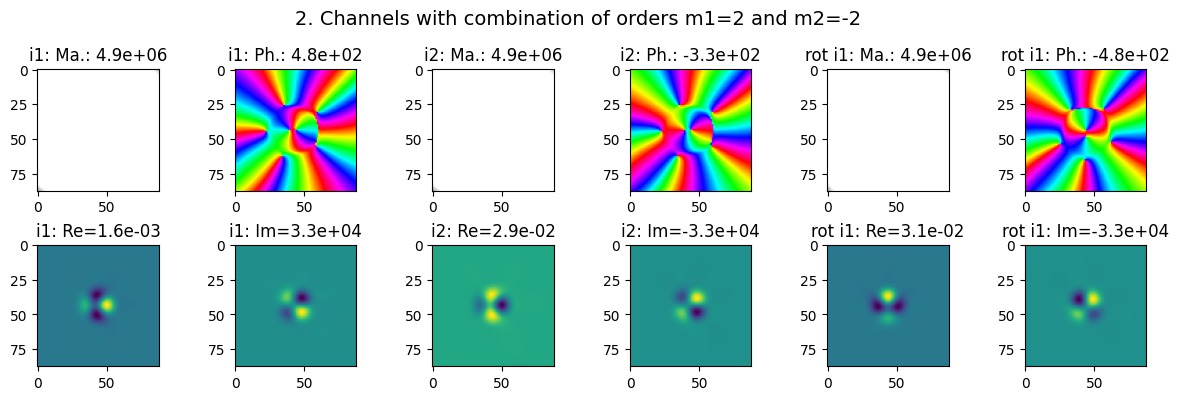

In [14]:
for idx, order in enumerate(kernel_orders2):
    fig, (axs1, axs2) = plt.subplots(2, 6, figsize=(12, 4))
    axs = axs1
    _ = plot_mag_phase(s_channels1[0][idx], f"i1", fig, axs[0], axs[1])
    _ = plot_mag_phase(s_channels2[0][idx], f"i2", fig, axs[2], axs[3])
    _ = plot_mag_phase(s_channels_rot1[0][idx], f"rot i1", fig, axs[4], axs[5])
    axs = axs2
    _ = plot_complex(s_channels1[0][idx], f"i1", fig, axs[0], axs[1])
    _ = plot_complex(s_channels2[0][idx], f"i2", fig, axs[2], axs[3])
    _ = plot_complex(s_channels_rot1[0][idx], f"rot i1", fig, axs[4], axs[5])
    # Set xlabel for the the fig
    fig.suptitle(f"2. Channels with combination of orders m1={kernel_orders[idx]} and m2={order}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [16]:
p_10 = get_complex_monomial(i_1.shape[-1], 1, 0)

# Make convolution original input and the rotated version 
s_channels1_10 = torch.conv2d(repeat(i_1, 'h w -> 1 1 h w',), 
             weight=repeat(p_10, 'h w -> 1 1 h w'),
             )

ModuleNotFoundError: No module named 'src'